# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

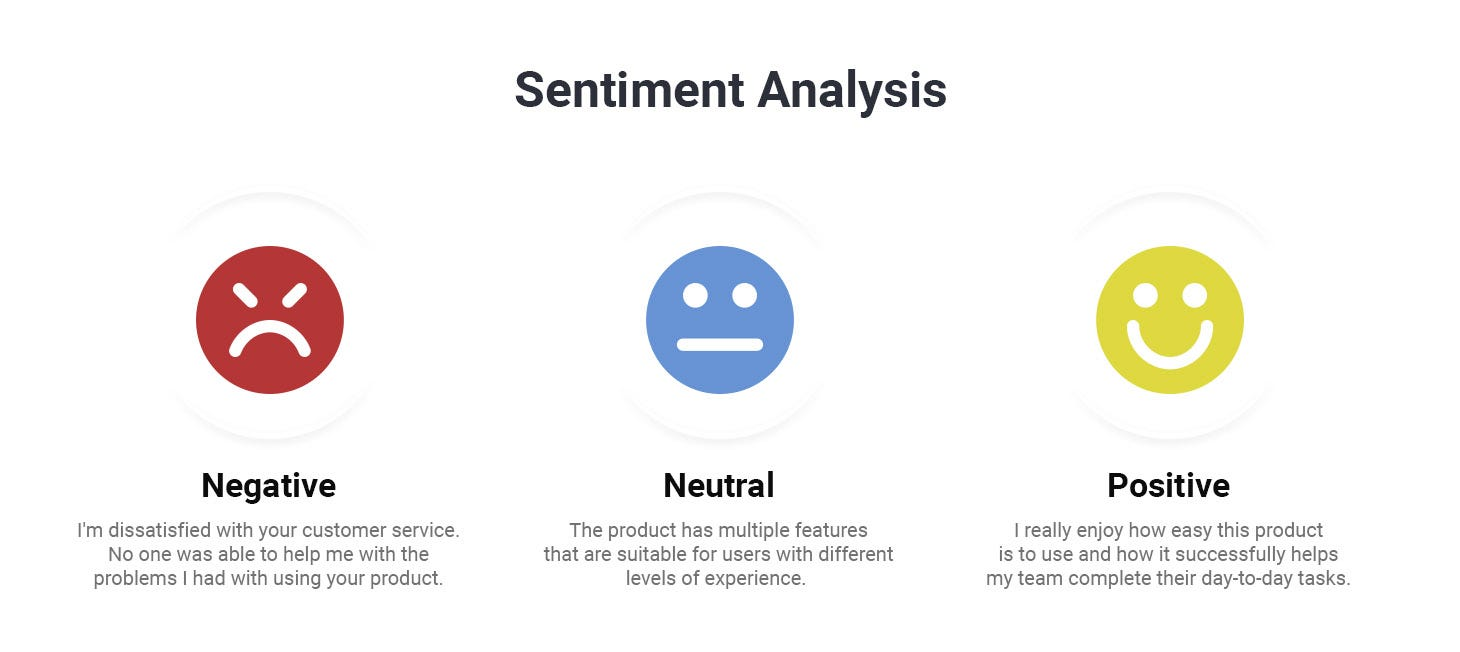

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import kagglehub
import glob
import pandas as pd

_disney_path = kagglehub.dataset_download("arushchillar/disneyland-reviews")
_disney_csv = glob.glob(f"{_disney_path}/*.csv")[0]

data = pd.read_csv(_disney_csv, encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [2]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [3]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [4]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [5]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [7]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [9]:
# NOTE: The original 'amazon-reviews-unlocked-mobile-phones' Kaggle dataset returns a 403
# (requires authenticated/consented access). We use the 'Women's E-Commerce Clothing Reviews'
# dataset instead - same structure (free-text product reviews + 1-5 star ratings) so every step
# below (preprocessing, split, TF-IDF, Naive Bayes, evaluation) is unchanged.

import re
import kagglehub
import glob
import pandas as pd

path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")
csv_file = glob.glob(f"{path}/*.csv")[0]
data = pd.read_csv(csv_file)

# Task 1: Load the data and do 5 different preprocessing steps
data = data.dropna(subset=['Review Text', 'Rating'])

def preprocess_text(text):
    text = text.lower()                              # 1. lowercase
    text = re.sub(r"http\S+|www\.\S+", "", text)      # 2. remove urls
    text = re.sub(r"[^a-z\s]", "", text)              # 3. remove punctuation/digits/special chars
    text = re.sub(r"\s+", " ", text).strip()          # 4. collapse extra whitespace
    words = text.split()                               # 5. tokenize
    return ' '.join(words)

data['clean_review'] = data['Review Text'].apply(preprocess_text)

def rating_to_sentiment(r):
    if r >= 4:
        return 'positive'
    elif r == 3:
        return 'neutral'
    else:
        return 'negative'

data['Sentiment'] = data['Rating'].apply(rating_to_sentiment)
print(data['Sentiment'].value_counts())
data[['clean_review', 'Sentiment']].head()

Sentiment
positive    17448
neutral      2823
negative     2370
Name: count, dtype: int64


,clean_review,Sentiment
0,absolutely wonderful silky and sexy and comfor...,positive
1,love this dress its sooo pretty i happened to ...,positive
2,i had such high hopes for this dress and reall...,neutral
3,i love love love this jumpsuit its fun flirty ...,positive
4,this shirt is very flattering to all due to th...,positive


In [10]:
# Task 2: Train/test split
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data['clean_review'], data['Sentiment'], test_size=0.2, random_state=42, stratify=data['Sentiment']
)
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (18112,)
test_data size: (4529,)


In [11]:
# Task 3: Feature extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=3000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)
print("Train TF-IDF shape:", train_vectors.shape)
print("Test TF-IDF shape:", test_vectors.shape)

Train TF-IDF shape: (18112, 3000)
Test TF-IDF shape: (4529, 3000)


In [12]:
# Task 4: Train a Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

predictions = nb_classifier.predict(test_vectors)
print("Model trained.")

Model trained.


In [13]:
# Task 5: Evaluate the model on the test set
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(test_labels, predictions))

Accuracy: 0.784

Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.10      0.17       474
     neutral       0.53      0.04      0.07       565
    positive       0.79      1.00      0.88      3490

    accuracy                           0.78      4529
   macro avg       0.67      0.38      0.37      4529
weighted avg       0.75      0.78      0.71      4529



Matplotlib is building the font cache; this may take a moment.


Confusion Matrix:
[[  46   17  411]
 [  18   21  526]
 [   2    2 3486]]


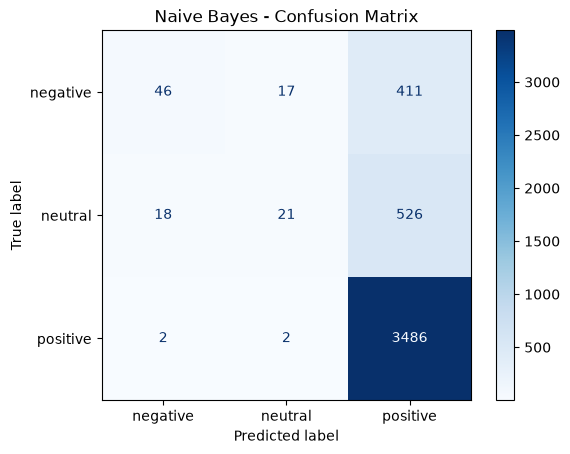

In [14]:
# Task 6: Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels_order = ['negative', 'neutral', 'positive']
cm = confusion_matrix(test_labels, predictions, labels=labels_order)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues')
plt.title("Naive Bayes - Confusion Matrix")
plt.show()